# **模块**: 单变量统计过程监控
## **课程**: Shewhart控制图
### *主题*:  均值漂移0.5倍标准差的Shewhart控制图 

In [1]:
# 导入所需包
import numpy as np
import matplotlib.pyplot as plt
# 中文显示设置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


np.random.seed(10)

In [2]:
# ==================================================================================
#                        生成无故障样本
# ==================================================================================

> ##### 首先生成若干无故障样本作为模型训练数据集

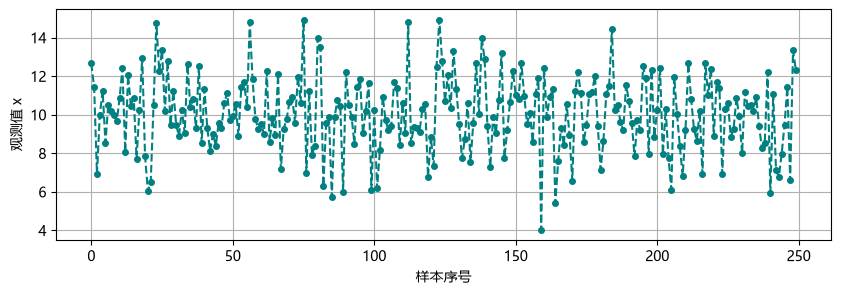

In [3]:
# 生成NOC（正常运行工况）数据
N = 250 # 250 observation samples
x_faultFree = np.random.normal(loc=10, scale=2, size=N) # mean=10; standard deviation=2

# 绘制NOC数据
plt.figure(figsize=(10,3))
plt.plot(x_faultFree,'--', marker='o', markersize=4, color='teal')
plt.xlabel('样本序号'), plt.ylabel('观测值 x')
plt.grid()
plt.show()


In [4]:
# ==================================================================================
#                                    模型训练
# ==================================================================================

> ##### 将使用NOC数据估计Shewhart控制图参数：信号的均值(mu)和标准差(sigma)

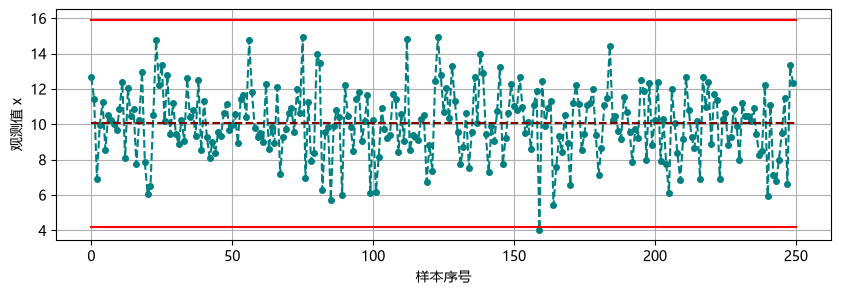

In [5]:
# 估计Shewhart模型参数并为NOC数据绘制控制图
mu, sigma = np.mean(x_faultFree), np.std(x_faultFree)
UCL, LCL = mu + 3*sigma, mu - 3*sigma

plt.figure(figsize=(10,3))
plt.plot(x_faultFree,'--', marker='o', markersize=4, color='teal')
plt.plot([0,N], [UCL,UCL], color='red'), plt.plot([0,N],[LCL,LCL], color='red')
plt.plot([0,N], [mu,mu], '--', color='maroon')
plt.xlabel('样本序号'), plt.ylabel('观测值 x')
plt.grid()
plt.show()

In [6]:
# ==================================================================================
#               生成故障样本并绘制在控制图上
# ==================================================================================

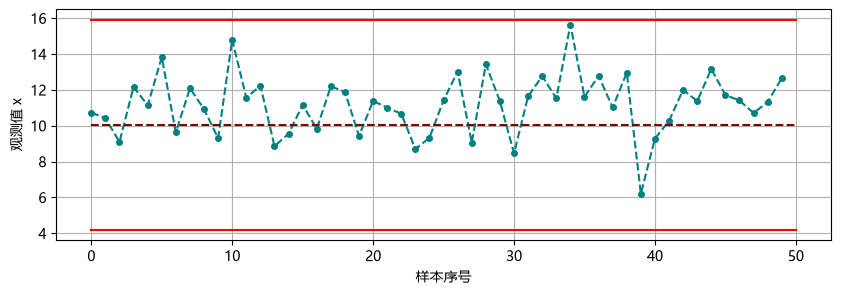

In [7]:
# 故障数据
N_faulty = 50 # 50 observation samples
x_faulty = np.random.normal(loc=11, scale=2, size=N_faulty) # mean=10+0.5*2; standard deviation=2

# 故障数据的控制图
plt.figure(figsize=(10,3))
plt.plot(x_faulty,'--', marker='o', markersize=4, color='teal')
plt.plot([0,N_faulty], [UCL,UCL], color='red'), plt.plot([0,N_faulty],[LCL,LCL], color='red')
plt.plot([0,N_faulty], [mu,mu], '--', color='maroon')
plt.xlabel('样本序号'), plt.ylabel('观测值 x')
plt.grid()
plt.show()

In [8]:
# ==================================================================================
#         所有样本（无故障与故障）合并的控制图
# ==================================================================================

In [9]:
# 合并数据
x_combined = np.hstack((x_faultFree,x_faulty))
print(f'无故障样本 x_faultfree 形状 = {x_faultFree.shape}')
print(f'故障样本 x_faulty 形状 = {x_faulty.shape}')
print(f'合并样本 x_combined 形状 = {x_combined.shape}')

无故障样本 x_faultfree 形状 = (250,)
故障样本 x_faulty 形状 = (50,)
合并样本 x_combined 形状 = (300,)


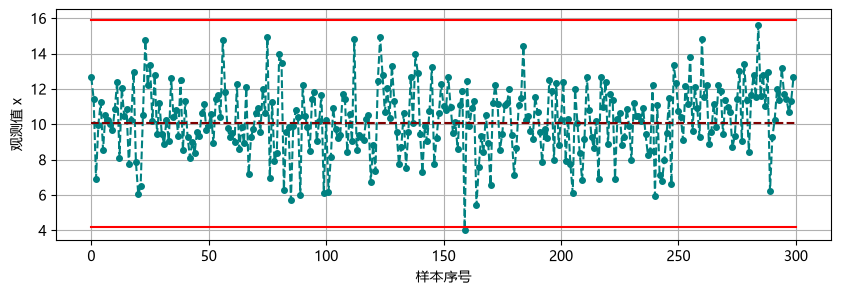

In [10]:
# 合并数据的控制图
plt.figure(figsize=(10,3))
plt.plot(x_combined,'--',marker='o', markersize=4, color='teal')
plt.plot([0,len(x_combined)], [UCL,UCL], color='red')
plt.plot([0,len(x_combined)], [LCL,LCL], color='red')
plt.plot([0,len(x_combined)], [mu,mu], '--', color='maroon')
plt.xlabel('样本序号'), plt.ylabel('观测值 x')
plt.grid()
plt.show()